In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np

In [2]:
envs = ["atari_battle_zone", "atari_double_dunk", "atari_phoenix", "atari_this_game", "atari_battle_zone", "box2d_lunar_lander", "box2d_continuous_lunar_lander", "box2d_bipedal_walker", "cc_acrobot", "cc_cartpole", "cc_mountain_car", "cc_continuous_mountain_car", "cc_pendulum", "minigrid_door_key", "minigrid_empty_random", "minigrid_four_rooms", "minigrid_unlock", "brax_ant", "brax_halfcheetah", "brax_hopper", "brax_humanoid"]
algos = ["ppo", "dqn", "sac"]

data = []
for env in envs:
    for algo in algos:
        try:
            partial_data = pd.read_csv(f"arlbench_data/256_10/{env}_{algo}.csv")
            partial_data["env_name"] = env
            partial_data["algorithm"] = algo
            data.append(partial_data)
        except FileNotFoundError:
            continue
data = pd.concat(data)

## 1. Normalize performance values

### a) similarly to last_performance (per alg & env)

In [3]:
from sklearn.linear_model import LinearRegression

In [4]:
# normalization coefficients 
# {"{alg}-{env}": (coef, intercept)} 
# where normalized = coef * unnormalized + intercept

normalization_coefficients = {}

for env in data["env_name"].unique():
    for alg in data["algorithm"].unique():

        data_subset = data[(data["algorithm"] == alg) & (data["env_name"] == env)]

        try:
            X = data_subset[["last_performance_unnormalized"]]
            y = data_subset["last_performance"]
            reg = LinearRegression().fit(X, y)
            normalization_coefficients[f"{alg}-{env}"] = (reg.coef_[0], reg.intercept_)
        except ValueError:
            # print(f"Not enough data for {env} and {alg}")
            continue

### b) per env, but cross algorithms

In [5]:
## Alternatively: Normalize Cross algorithms in a single environment

normalization_coefficients_cross_alg = {}

for env in data["env_name"].unique():

    env_data = data[(data["env_name"] == env)]

    max_performance = env_data["performance"].max()
    min_performance = env_data["performance"].min()

    coef = 1 / (max_performance - min_performance) if max_performance != min_performance else 1.0
    intercept = -min_performance * coef

    normalization_coefficients_cross_alg[env] = (coef, intercept)

## 2. Calc performance profiles

In [6]:
def compute_performance_profile(df, 
                                tau_values,
                                norm_d: dict,
                                key: str = "alg-env"
                                ):
    """
    Compute performance profile based on:
    (1/M) * sum_m (1/HS) * sum_h sum_s 1_{x_{m,h,s} > tau}
    
    Where:
    - m = env_name
    - h = config_id
    - s = seed
    """
    results = []
    
    for algo in df["algorithm"].unique():
        algo_data = df[df["algorithm"] == algo]
        
        for tau in tau_values:
            env_scores = []
            
            for env in algo_data["env_name"].unique():
                env_data = algo_data[algo_data["env_name"] == env]
                
                # Count how many (config, seed) pairs exceed tau
                H = env_data["config_id"].nunique()
                S = env_data.groupby("config_id").size().max()  # seeds per config
                HS = len(env_data)  # total (config, seed) pairs

                coef = norm_d[f"{algo}-{env}"][0] if key == "alg-env" else norm_d[env][0]
                intercept = norm_d[f"{algo}-{env}"][1] if key == "alg-env" else norm_d[env][1]
                
                indicator_sum = (
                    (env_data["performance"] * coef + intercept)
                    > tau
                    ).sum()
                env_score = indicator_sum / HS
                env_scores.append(env_score)
            
            # Average over environments
            mean_score = np.mean(env_scores)
            results.append({
                "algorithm": algo,
                "tau": tau,
                "performance_profile": mean_score
            })
    
    return pd.DataFrame(results)


In [7]:
def compute_performance_profile(
    df, 
    tau_values,
    norm_d: dict,
    key: str = "alg-env",
    n_bootstrap: int = 1,
    confidence: float = 0.95
):
    """
    Compute performance profile with bootstrapping:
    - Stratified over envs (always include all envs)
    - Bootstrapped over (config_id, seed) pairs within each env
    
    Returns DataFrame with mean, lower CI, and upper CI.
    """
    results = []
    alpha = (1 - confidence) / 2
    
    for algo in df["algorithm"].unique():
        algo_data = df[df["algorithm"] == algo]
        envs = algo_data["env_name"].unique()
        
        for tau in tau_values:
            bootstrap_scores = []
            
            for _ in range(n_bootstrap):
                env_scores = []
                
                for env in envs:
                    env_data = algo_data[algo_data["env_name"] == env]
                    
                    # Bootstrap sample within this env (sample with replacement)
                    boot_sample = env_data.sample(n=len(env_data), replace=True)
                    
                    HS = len(boot_sample)
                    
                    coef = norm_d[f"{algo}-{env}"][0] if key == "alg-env" else norm_d[env][0]
                    intercept = norm_d[f"{algo}-{env}"][1] if key == "alg-env" else norm_d[env][1]
                    
                    indicator_sum = (
                        (boot_sample["performance"] * coef + intercept) > tau
                    ).sum()
                    env_score = indicator_sum / HS
                    env_scores.append(env_score)
                
                # Average over environments (stratified)
                bootstrap_scores.append(np.mean(env_scores))
            
            # Compute statistics
            mean_score = np.mean(bootstrap_scores)
            ci_lower = np.percentile(bootstrap_scores, alpha * 100)
            ci_upper = np.percentile(bootstrap_scores, (1 - alpha) * 100)
            
            results.append({
                "algorithm": algo,
                "tau": tau,
                "performance_profile": mean_score,
                "ci_lower": ci_lower,
                "ci_upper": ci_upper
            })
    
    return pd.DataFrame(results)

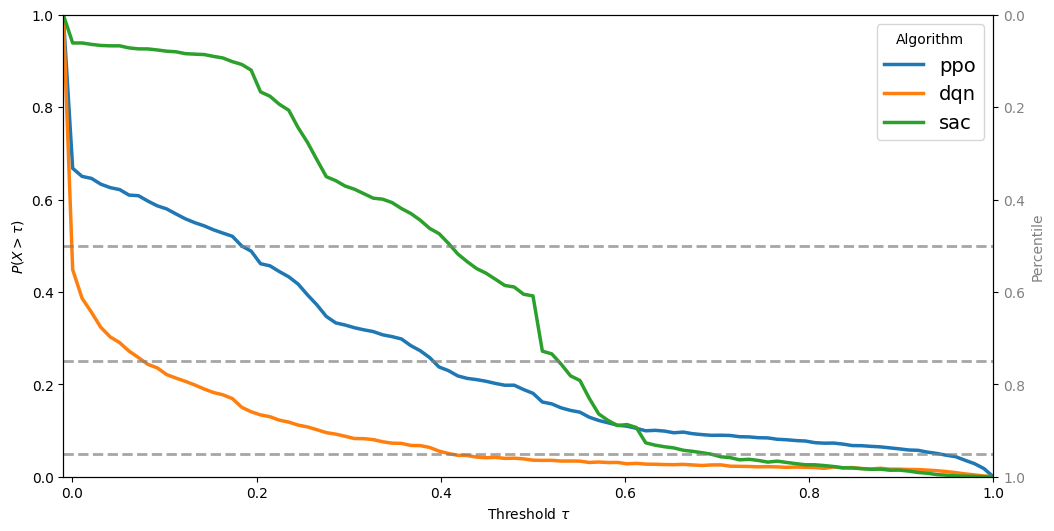

In [33]:
tau_min = -0.01
tau_max = 1.0
tau_values = np.linspace(tau_min, tau_max, 100)

# Compute performance profiles
performance_profiles = compute_performance_profile(data, tau_values, normalization_coefficients_cross_alg, key="env")

# Plot
fig, ax1 = plt.subplots(figsize=(12, 6))

# Get the color palette
palette = sns.color_palette()
algo_list = performance_profiles["algorithm"].unique()
algo_colors = {algo: palette[i] for i, algo in enumerate(algo_list)}

sns.lineplot(
    data=performance_profiles,
    x="tau",
    y="performance_profile",
    hue="algorithm",
    ax=ax1,
    linewidth=2.5
)

ax1.set_xlabel(r"Threshold $\tau$")
ax1.set_ylabel(r"$P(X > \tau)$")
ax1.set_ylim(0, 1)
ax1.set_xlim(tau_min, tau_max)

# Horizontal threshold values
h_lines = [0.25, 0.50, 0.05]

# Add horizontal lines
for h in h_lines:
    ax1.axhline(y=h, color='gray', linestyle='--', linewidth=2, alpha=0.7)

# Secondary y-axis (P(X <= tau))
ax2 = ax1.twinx()
ax2.set_ylim(1, 0)  # Flipped scale
ax2.set_ylabel(r"Percentile", color='gray')
ax2.tick_params(axis='y', labelcolor='gray')

# ax1.set_title("Performance Profiles by Algorithm")
ax1.legend(title="Algorithm", fontsize=14)
# plt.tight_layout()
plt.savefig("_figures/perf_profiles_per_alg.pdf")

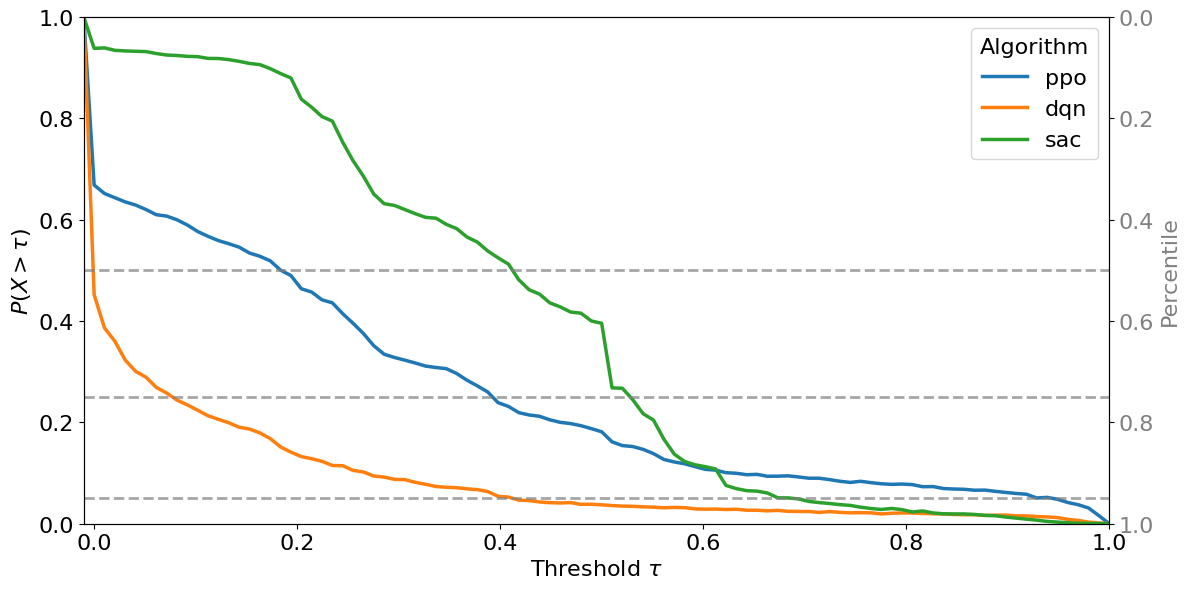

In [35]:
tau_min = -0.01
tau_max = 1.0
tau_values = np.linspace(tau_min, tau_max, 100)

# Compute performance profiles
performance_profiles = compute_performance_profile(data, tau_values, normalization_coefficients_cross_alg, key="env")

# Plot
fig, ax1 = plt.subplots(figsize=(12, 6))

# Get the color palette
palette = sns.color_palette()
algo_list = performance_profiles["algorithm"].unique()
algo_colors = {algo: palette[i] for i, algo in enumerate(algo_list)}

sns.lineplot(
    data=performance_profiles,
    x="tau",
    y="performance_profile",
    hue="algorithm",
    ax=ax1,
    linewidth=2.5
)

ax1.set_xlabel(r"Threshold $\tau$", fontsize=16)
ax1.set_ylabel(r"$P(X > \tau)$", fontsize=16)
ax1.set_ylim(0, 1)
ax1.set_xlim(tau_min, tau_max)
ax1.tick_params(axis='both', labelsize=16)

# Horizontal threshold values
h_lines = [0.25, 0.50, 0.05]

# Add horizontal lines
for h in h_lines:
    ax1.axhline(y=h, color='gray', linestyle='--', linewidth=2, alpha=0.7)

# Secondary y-axis (P(X <= tau))
ax2 = ax1.twinx()
ax2.set_ylim(1, 0)  # Flipped scale
ax2.set_ylabel(r"Percentile", color='gray', fontsize=16)
ax2.tick_params(axis='y', labelcolor='gray', labelsize=16)

# ax1.set_title("Performance Profiles by Algorithm")
ax1.legend(title="Algorithm", fontsize=16, title_fontsize=16)
plt.tight_layout()
plt.savefig("_figures/perf_profiles_per_alg.pdf")

In [10]:
def compute_ecdf(
    df, 
    norm_d: dict,
    key: str = "alg-env",
):
    """
    Compute empirical CDF for each algorithm.
    
    Returns DataFrame with normalized performance values and cumulative probabilities.
    """
    results = []
    
    for algo in df["algorithm"].unique():
        algo_data = df[df["algorithm"] == algo]
        
        # Collect all normalized performance values
        normalized_values = []
        
        for env in algo_data["env_name"].unique():
            env_data = algo_data[algo_data["env_name"] == env]
            
            coef = norm_d[f"{algo}-{env}"][0] if key == "alg-env" else norm_d[env][0]
            intercept = norm_d[f"{algo}-{env}"][1] if key == "alg-env" else norm_d[env][1]
            
            normalized = env_data["performance"] * coef + intercept
            normalized_values.extend(normalized.tolist())
        
        # Sort values and compute eCDF
        sorted_values = np.sort(normalized_values)
        n = len(sorted_values)
        ecdf_y = np.arange(1, n + 1) / n * 100  # Convert to percentage
        
        for x, y in zip(sorted_values, ecdf_y):
            results.append({
                "algorithm": algo,
                "normalized_performance": x * 100,  # Convert to percentage
                "ecdf": y
            })
    
    return pd.DataFrame(results)

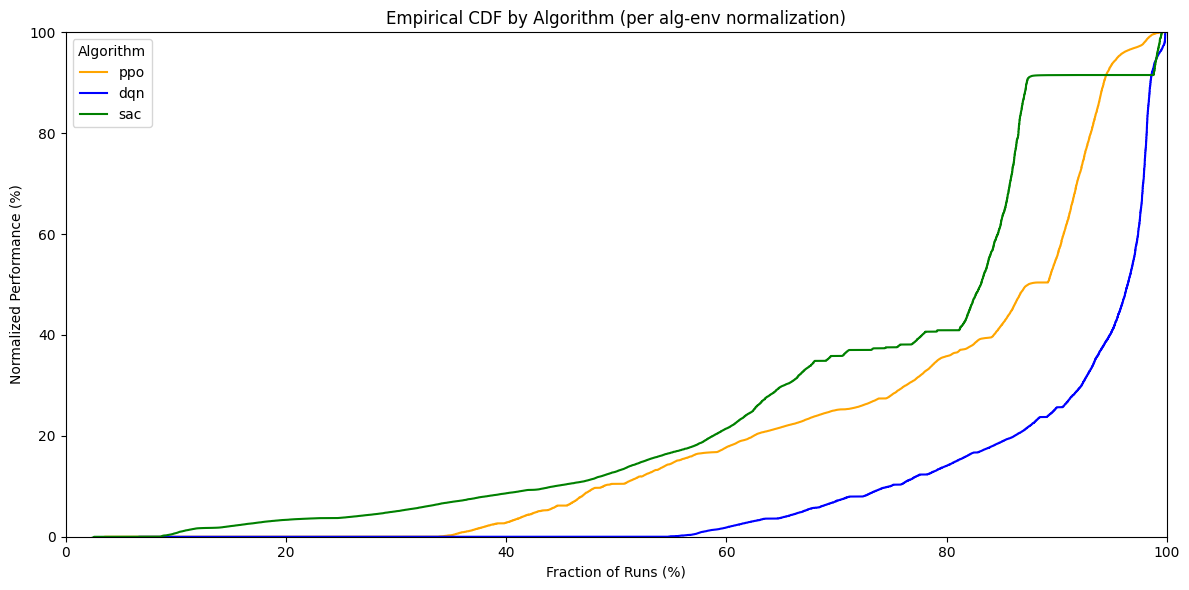

In [13]:
ecdf_data = compute_ecdf(data, normalization_coefficients, key="alg-env")

# Plot
algo_colors = {"sac": "green", "ppo": "orange", "dqn": "blue"}

plt.figure(figsize=(12, 6))
for algo in ecdf_data["algorithm"].unique():
    algo_subset = ecdf_data[ecdf_data["algorithm"] == algo]
    plt.step(
        algo_subset["ecdf"],
        algo_subset["normalized_performance"], 
        where="pre",
        label=algo,
        color=algo_colors[algo]
    )

plt.ylabel("Normalized Performance (%)")
plt.xlabel("Fraction of Runs (%)")
plt.title("Empirical CDF by Algorithm (per alg-env normalization)")
plt.legend(title="Algorithm")
plt.ylim(0, 100)
plt.xlim(0, 100)
plt.tight_layout()

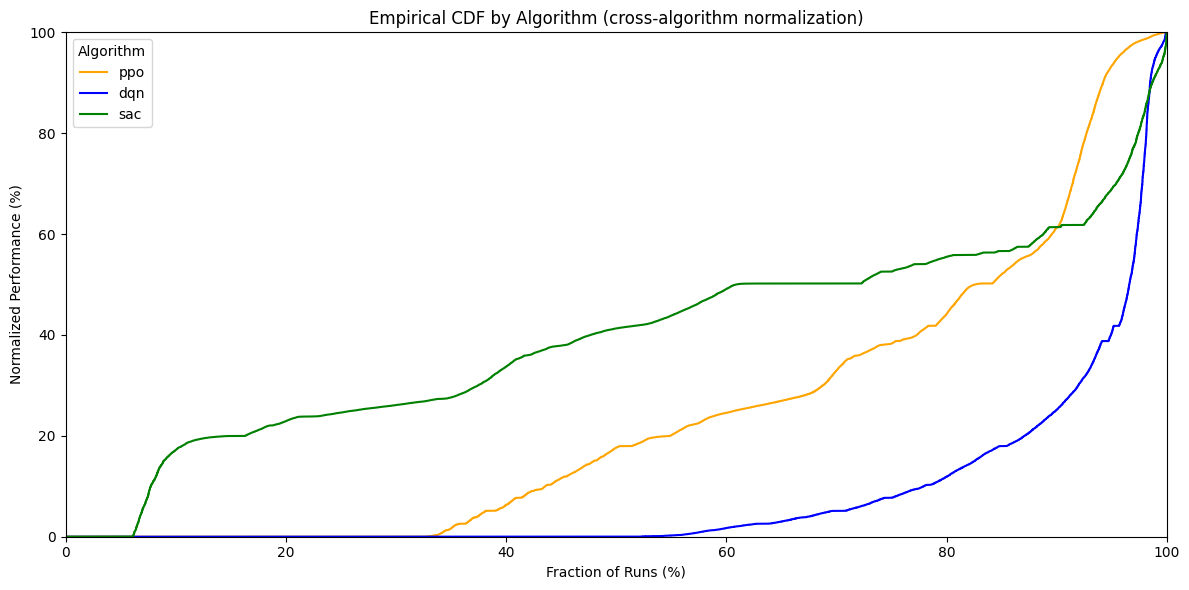

In [14]:
# // Replace the second eCDF plotting cell

# Compute eCDFs with cross-algorithm normalization
ecdf_data_cross = compute_ecdf(data, normalization_coefficients_cross_alg, key="env")

# Plot
algo_colors = {"sac": "green", "ppo": "orange", "dqn": "blue"}

plt.figure(figsize=(12, 6))
for algo in ecdf_data_cross["algorithm"].unique():
    algo_subset = ecdf_data_cross[ecdf_data_cross["algorithm"] == algo]
    plt.step(
        algo_subset["ecdf"],
        algo_subset["normalized_performance"], 
        where="pre",
        label=algo,
        color=algo_colors[algo]
    )

plt.ylabel("Normalized Performance (%)")
plt.xlabel("Fraction of Runs (%)")
plt.title("Empirical CDF by Algorithm (cross-algorithm normalization)")
plt.legend(title="Algorithm")
plt.ylim(0, 100)
plt.xlim(0, 100)
plt.tight_layout()